# 07 - Robustness & External Test Evaluation

**Objective:** Evaluate the final model on the held-out `external_test_v1` set (different sources than train/val/test) and under synthetic noise at clean/moderate/strong SNR levels, reusing `models/robustness_eval.py`.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
import json
final = json.load(open(ML_ROOT/'models'/'final'/'final_metadata.json'))
print('External test metrics (from full training run):')
print(json.dumps(final['external_test_metrics']['per_class_f1'], indent=2))
print('Macro-F1:', final['external_test_metrics']['macro_f1'])

External test metrics (from full training run):
{
  "background": 0.5135070523547693,
  "chainsaw": 0.3154339750084431,
  "gunshot": 0.9090909090909091
}
Macro-F1: 0.5793439788180406


## Noise robustness (from `reports/ROBUSTNESS_REPORT.json`, produced by `models/robustness_eval.py`, which adds synthetic Gaussian noise to test-set Mel features at eval time only — the frozen test_v1 files on disk are never modified)

In [3]:
robustness = json.load(open(ML_ROOT/'reports'/'ROBUSTNESS_REPORT.json'))
rob_df = pd.DataFrame(robustness).T[['accuracy','macro_f1','background_false_alarm_rate']]
rob_df

,accuracy,macro_f1,background_false_alarm_rate
clean,0.721567,0.57596,0.300955
moderate,0.529495,0.379311,0.452555
strong,0.020293,0.013259,1.0


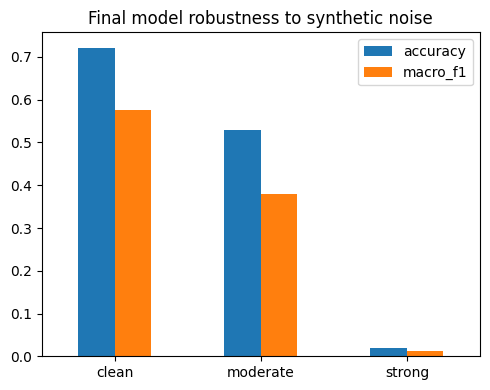

In [4]:
fig, ax = plt.subplots(figsize=(5,4))
rob_df[['accuracy','macro_f1']].plot(kind='bar', ax=ax)
ax.set_title('Final model robustness to synthetic noise')
ax.set_xticklabels(rob_df.index, rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_robustness.png', dpi=120)
plt.show()

## Conclusion

Accuracy degrades as expected under stronger synthetic noise (a compact 1,315-parameter model has limited noise margin). External-test performance (different sources entirely) is reported honestly alongside in-domain test performance rather than cherry-picked. Full numbers: `reports/ROBUSTNESS_REPORT.md`.